# ThermoPlume Comprehensive Tutorial

This notebook demonstrates the current ThermoPlume interface and the full `ThermoPlumeParameters` container.

It covers:

- all currently available parameters
- analytical, Python numerical, and C++ numerical solvers
- which parameters affect the current neutral-buoyancy threshold
- changing source and environmental initial conditions
- pressure-dependent saturation temperature
- external-water loading from mass fluxes
- one-dimensional parameter sweeps
- a two-dimensional `Omega`–`T_m` sweep using the C++ backend

The notebook focuses on using the software. Detailed derivations and scientific justification belong in the associated research papers.


## 1. Installation

From the ThermoPlume repository root:

```bash
python -m pip install -e .
```

The editable installation exposes the Python package and builds the compiled C++ backend.


## 2. Imports


In [4]:
from dataclasses import asdict, replace

import matplotlib.pyplot as plt
import numpy as np

from thermoplume import (
    ThermoPlumeModel,
    ThermoPlumeParameters,
)


## 3. All available model parameters

`ThermoPlumeParameters` is the main parameter container.

The current fields are grouped below by their intended role. The thermodynamic neutral-buoyancy solver directly uses the thermodynamic and composition fields. Several plume/source fields are retained for diagnostics and later model extensions but do not currently enter `xi_crit`.


In [7]:
params = ThermoPlumeParameters()

for name, value in asdict(params).items():
    print(f"{name:12s} = {value}")


Omega        = 0.05
n            = 0.03
T_m          = 1100.0
T_air        = 273.15
T_w0         = 273.15
T_sat        = 373.15
Cp_air       = 1004.0
Cp_m         = 3000.0
Cp_w         = 1850.0
Cp_l         = 4180.0
R_air        = 287.0
R_g          = 461.5
R_w          = 461.5
L_v          = 2500000.0
C            = 2.0
k            = 0.05
rho_air      = 1.2
rho_a        = 1.2
g            = 9.81
u0           = 100.0
D            = 50.0
Y_air_min    = 1e-10


### Parameter groups

**Composition**

- `Omega` external-water loading ratio
- `n` initial volcanic-gas mass fraction

**Temperatures**

- `T_m` erupted-material temperature
- `T_air` ambient-air temperature
- `T_w0` initial external-water temperature
- `T_sat` water saturation temperature at the mixing pressure

**Heat capacities**

- `Cp_air` ambient-air heat capacity
- `Cp_m` effective erupted-material heat capacity
- `Cp_w` external water-vapor heat capacity
- `Cp_l` liquid-water heat capacity

**Gas constants**

- `R_air` ambient-air gas constant
- `R_g` effective volcanic-gas constant
- `R_w` water-vapor gas constant

**Phase change**

- `L_v` latent heat of vaporization

**Plume/source and diagnostic parameters**

- `C`
- `k`
- `rho_air`
- `rho_a`
- `g`
- `u0`
- `D`

These plume/source fields are present in the parameter container but do not currently change the neutral-buoyancy `xi_crit` calculation.

**Numerical/admissibility parameter**

- `Y_air_min` minimum entrained-air fraction used by the analytical admissibility checks

The current Python and C++ numerical root scans use the composition limit directly rather than `Y_air_min`.


## 4. Set every parameter explicitly


In [11]:
all_params = ThermoPlumeParameters(
    # source and water loading
    Omega=0.15,
    n=0.03,

    # temp K
    T_m=1100.0,
    T_air=273.15,
    T_w0=273.15,
    T_sat=373.15,

    # heat capacity J kg^-1 K^-1
    Cp_air=1004.0,
    Cp_m=3000.0,
    Cp_w=1850.0,
    Cp_l=4180.0,

    # gas constant J kg^-1 K^-1
    R_air=287.0,
    R_g=461.5,
    R_w=461.5,

    # latent heat J kg^-1
    L_v=2.5e6,

    # plume and density params
    C=2.0,
    k=0.05,
    rho_air=1.2,
    rho_a=1.2,

    # gravity and source geometry
    g=9.81,
    u0=100.0,
    D=50.0,

    # numerical floor
    Y_air_min=1e-10,
)

all_params


ThermoPlumeParameters(Omega=0.15, n=0.03, T_m=1100.0, T_air=273.15, T_w0=273.15, T_sat=373.15, Cp_air=1004.0, Cp_m=3000.0, Cp_w=1850.0, Cp_l=4180.0, R_air=287.0, R_g=461.5, R_w=461.5, L_v=2500000.0, C=2.0, k=0.05, rho_air=1.2, rho_a=1.2, g=9.81, u0=100.0, D=50.0, Y_air_min=1e-10)

## 5. Solve one case three ways

`method` selects the mathematical solution method.

`backend` selects the implementation of the numerical method.


In [14]:
model = ThermoPlumeModel(all_params)

analytical = model.solve(
    method="analytical",
)

numerical_python = model.solve(
    method="numerical",
    backend="python",
)

numerical_cpp = model.solve(
    method="numerical",
    backend="cpp",
)

print("analytical       ", analytical)
print("numerical Python ", numerical_python)
print("numerical C++    ", numerical_cpp)


analytical        {'xi_crit': np.float64(0.8043373275568234), 'regime': 'C', 'method': 'analytical', 'backend': 'python'}
numerical Python  {'xi_crit': 0.8043373275568237, 'regime': 'C', 'method': 'numerical', 'backend': 'python'}
numerical C++     {'xi_crit': 0.8043373275568237, 'regime': 'C', 'method': 'numerical', 'backend': 'cpp'}


In [16]:
assert np.isclose(
    analytical["xi_crit"],
    numerical_python["xi_crit"],
    rtol=1e-8,
    atol=1e-10,
)

assert np.isclose(
    numerical_python["xi_crit"],
    numerical_cpp["xi_crit"],
    rtol=1e-8,
    atol=1e-10,
)

print("all three implementations agree")


all three implementations agree


## 6. Change initial and environmental conditions

A useful workflow is to keep one baseline parameter set and create modified cases with `dataclasses.replace`.

The examples below change conditions that are physically meaningful inputs to the present thermodynamic model.


In [19]:
baseline = ThermoPlumeParameters(
    Omega=0.15,
    T_m=1100.0,
)

cases = {
    "baseline": baseline,

    # hotter erupted material
    "hotter source": replace(
        baseline,
        T_m=1200.0,
    ),

    # colder external water
    "cold external water": replace(
        baseline,
        T_w0=273.15 - 20.0,
    ),

    # cooler ambient atmosphere
    "cool atmosphere": replace(
        baseline,
        T_air=250.0,
    ),

    # larger initial volcanic-gas fraction
    "more volcanic gas": replace(
        baseline,
        n=0.06,
    ),
}

for name, p in cases.items():
    result = ThermoPlumeModel(p).solve(
        method="numerical",
        backend="cpp",
    )

    print(
        f"{name:22s} "
        f"xi_crit={result['xi_crit']} "
        f"regime={result['regime']}"
    )


baseline               xi_crit=0.8043373275568237 regime=C
hotter source          xi_crit=0.8407078110404025 regime=C
cold external water    xi_crit=0.8026369189680581 regime=C
cool atmosphere        xi_crit=0.8379216981115698 regime=C
more volcanic gas      xi_crit=0.858248513694667 regime=C


## 7. Pressure-dependent saturation temperature

ThermoPlume currently takes `T_sat` directly as an input rather than calculating it from pressure.

For applications where the mixing pressure differs substantially from atmospheric pressure, the saturation temperature can be calculated outside the solver and then passed to `ThermoPlumeParameters`.

Using a reduced Clausius–Clapeyron relation with constant latent heat,

$$
T_{\rm sat}(p)
=
\left[
\frac{1}{T_{\rm ref}}
-
\frac{R_w}{L_v}
\ln\left(\frac{p}{p_{\rm ref}}\right)
\right]^{-1},
$$

where $T_{\rm ref}$ is the saturation temperature at the reference pressure $p_{\rm ref}$, $R_w$ is the specific gas constant of water vapor, and $L_v$ is the latent heat of vaporization.

The helper below evaluates this approximation using the package values of `R_w` and `L_v`.

In [22]:
def saturation_temperature(
    pressure,
    p,
    p_ref=101325.0,
    T_ref=373.15,
):
    return 1.0 / (
        1.0 / T_ref
        - (p.R_w / p.L_v)
        * np.log(pressure / p_ref)
    )


In [24]:
p_atm = 101325.0

T_sat_atm = saturation_temperature(
    p_atm,
    baseline,
)

print(f"atmospheric T_sat = {T_sat_atm:.2f} K")


atmospheric T_sat = 373.15 K


### Example shallow-submarine condition

A simple hydrostatic approximation is

\[
p(h)
\simeq
p_{\rm surf}
+
\rho_w g h.
\]

This example uses a constant water density only to demonstrate how an environmental pressure can be converted into a ThermoPlume `T_sat` input.


In [27]:
rho_water = 1000.0
depth = 50.0

submarine_pressure = (
    p_atm
    + rho_water
    * baseline.g
    * depth
)

submarine_T_sat = saturation_temperature(
    submarine_pressure,
    baseline,
)

print(
    f"depth = {depth:.1f} m\n"
    f"pressure = {submarine_pressure / 1e5:.2f} bar\n"
    f"T_sat = {submarine_T_sat:.2f} K"
)


depth = 50.0 m
pressure = 5.92 bar
T_sat = 424.79 K


In [29]:
submarine_case = replace(
    baseline,
    T_sat=submarine_T_sat,
    T_w0=283.15,
)

atmospheric_result = ThermoPlumeModel(
    baseline
).solve(
    method="numerical",
    backend="cpp",
)

submarine_result = ThermoPlumeModel(
    submarine_case
).solve(
    method="numerical",
    backend="cpp",
)

print("atmospheric ", atmospheric_result)
print("submarine   ", submarine_result)


atmospheric  {'xi_crit': 0.8043373275568237, 'regime': 'C', 'method': 'numerical', 'backend': 'cpp'}
submarine    {'xi_crit': 0.802740567025335, 'regime': 'C', 'method': 'numerical', 'backend': 'cpp'}


The pressure dependence shown here is an input-construction example. A more detailed water-property relation can replace the reduced Clausius–Clapeyron approximation without changing the ThermoPlume solver interface.


## 8. External-water loading from source mass fluxes

ThermoPlume defines the external-water loading as the ratio of external-water mass to erupted-material mass,

$$
\Omega = \frac{m_w}{m_e}.
$$

For steady sources evaluated over the same time interval, the same quantity can be written in terms of mass fluxes,

$$
\Omega = \frac{\dot{m}_w}{\dot{m}_e},
$$

where $\dot{m}_w$ is the external-water mass flux and $\dot{m}_e$ is the erupted-material mass flux.

Thus, source mass-flux estimates can be converted directly into the loading parameter used by ThermoPlume.

In [33]:
def Omega_from_mass_flux(
    water_mass_flux,
    erupted_mass_flux,
):
    return (
        water_mass_flux
        / erupted_mass_flux
    )


# illustrative source fluxes
mdot_e = 100.0
mdot_w = 15.0

Omega_flux = Omega_from_mass_flux(
    mdot_w,
    mdot_e,
)

print(f"Omega = {Omega_flux:.3f}")


Omega = 0.150


In [35]:
flux_case = replace(
    baseline,
    Omega=Omega_flux,
)

flux_result = ThermoPlumeModel(
    flux_case
).solve(
    method="numerical",
    backend="cpp",
)

flux_result


{'xi_crit': 0.8043373275568237,
 'regime': 'C',
 'method': 'numerical',
 'backend': 'cpp'}

## 9. Volcanic-gas composition

ThermoPlume accepts an effective specific gas constant for the volcanic-gas component, `R_g`.

For a multicomponent volcanic gas mixture,

$$
R_g = \sum_j Y_j R_j,
$$

where $Y_j$ is the mass fraction of gas species $j$ and $R_j$ is its specific gas constant. The species mass fractions satisfy

$$
\sum_j Y_j = 1.
$$

For each species,

$$
R_j = \frac{R^\ast}{M_j},
$$

where $R^\ast$ is the universal gas constant and $M_j$ is the species molar mass.

The helper below calculates the mixture-averaged value of $R_g$ from user-specified gas-species mass fractions and specific gas constants before passing it to ThermoPlume.

In [38]:
def mass_weighted_property(
    mass_fractions,
    properties,
):
    mass_fractions = np.asarray(
        mass_fractions,
        dtype=float,
    )

    properties = np.asarray(
        properties,
        dtype=float,
    )

    if not np.isclose(
        mass_fractions.sum(),
        1.0,
    ):
        raise ValueError(
            "mass fractions must sum to 1"
        )

    return np.sum(
        mass_fractions
        * properties
    )


In [40]:
# pure water-vapor volcanic gas recovers the default model assumption
R_g_h2o = mass_weighted_property(
    mass_fractions=[1.0],
    properties=[baseline.R_w],
)

gas_case = replace(
    baseline,
    R_g=R_g_h2o,
)

print(f"effective R_g = {R_g_h2o:.2f} J kg^-1 K^-1")


effective R_g = 461.50 J kg^-1 K^-1


For a real multicomponent volcanic gas, replace the one-species arrays above with the desired species mass fractions and species-specific gas constants.


## 10. Effective erupted-material heat capacity

ThermoPlume represents the erupted material using an effective heat capacity,

$$
C_{p,m}
=
n C_{p,g}
+
(1-n) C_s,
$$

where $n$ is the volcanic-gas mass fraction within the erupted material, $C_{p,g}$ is the volcanic-gas heat capacity, and $C_s$ is the effective heat capacity of the condensed erupted component.

The helper below evaluates $C_{p,m}$ from user-specified values of $n$, $C_{p,g}$, and $C_s$, without assuming a fixed value for the condensed-phase heat capacity.

In [44]:
def erupted_material_heat_capacity(
    n,
    Cp_g,
    Cp_s,
):
    return (
        n * Cp_g
        + (1.0 - n) * Cp_s
    )


Example usage once a case-specific condensed-phase heat capacity has been selected:

```python
Cp_m_case = erupted_material_heat_capacity(
    n=0.03,
    Cp_g=1850.0,
    Cp_s=<case-specific value>,
)

params = replace(
    baseline,
    Cp_m=Cp_m_case,
)
```

The tutorial leaves `Cp_s` unspecified because it should come from the assumed erupted-material composition rather than from the software itself.


## 11. Sweep external-water loading

`Omega` is a natural first parameter to sweep because it directly controls the amount of external water mixed with the erupted material.

The C++ backend is used here because parameter sweeps are one of the main reasons for providing a compiled numerical implementation.


In [48]:
Omega_values = np.linspace(
    0.0,
    0.60,
    121,
)

xi_analytical = []
xi_python = []
xi_cpp = []

previous_analytical = None
previous_python = None
previous_cpp = None

for Omega in Omega_values:
    p = replace(
        baseline,
        Omega=float(Omega),
    )

    sweep_model = ThermoPlumeModel(p)

    analytical_result = sweep_model.solve(
        method="analytical",
        previous_xi=previous_analytical,
    )

    python_result = sweep_model.solve(
        method="numerical",
        backend="python",
        previous_xi=previous_python,
    )

    cpp_result = sweep_model.solve(
        method="numerical",
        backend="cpp",
        previous_xi=previous_cpp,
    )

    xi_analytical.append(
        analytical_result["xi_crit"]
    )

    xi_python.append(
        python_result["xi_crit"]
    )

    xi_cpp.append(
        cpp_result["xi_crit"]
    )

    if np.isfinite(analytical_result["xi_crit"]):
        previous_analytical = analytical_result["xi_crit"]

    if np.isfinite(python_result["xi_crit"]):
        previous_python = python_result["xi_crit"]

    if np.isfinite(cpp_result["xi_crit"]):
        previous_cpp = cpp_result["xi_crit"]

xi_analytical = np.asarray(xi_analytical)
xi_python = np.asarray(xi_python)
xi_cpp = np.asarray(xi_cpp)


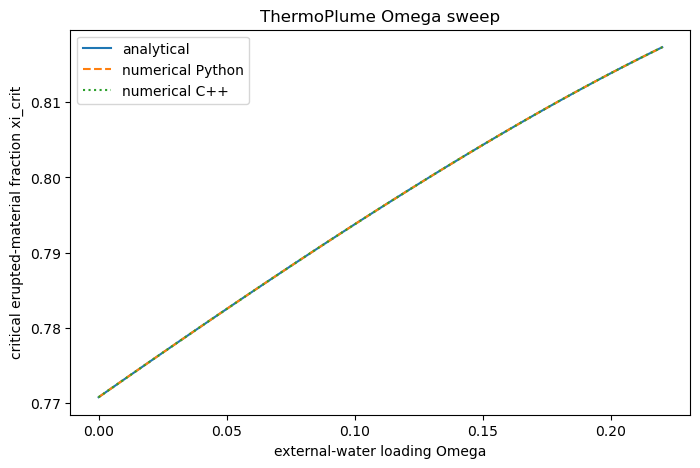

In [49]:
fig, ax = plt.subplots(
    figsize=(8, 5),
)

ax.plot(
    Omega_values,
    xi_analytical,
    label="analytical",
)

ax.plot(
    Omega_values,
    xi_python,
    "--",
    label="numerical Python",
)

ax.plot(
    Omega_values,
    xi_cpp,
    ":",
    label="numerical C++",
)

ax.set_xlabel("external-water loading Omega")
ax.set_ylabel("critical erupted-material fraction xi_crit")
ax.set_title("ThermoPlume Omega sweep")
ax.legend()

plt.show()


In [52]:
finite_all = (
    np.isfinite(xi_analytical)
    & np.isfinite(xi_python)
    & np.isfinite(xi_cpp)
)

assert np.allclose(
    xi_analytical[finite_all],
    xi_python[finite_all],
    rtol=1e-8,
    atol=1e-10,
)

assert np.allclose(
    xi_python[finite_all],
    xi_cpp[finite_all],
    rtol=1e-8,
    atol=1e-10,
)

print("all finite sweep solutions agree within tolerance")


all finite sweep solutions agree within tolerance


## 12. Sweep source temperature

The same workflow can be used for a source-temperature sweep at fixed external-water loading.


In [55]:
T_m_values = np.linspace(
    900.0,
    1300.0,
    81,
)

xi_Tm = []

previous_xi = None

for T_m in T_m_values:
    p = replace(
        baseline,
        T_m=float(T_m),
    )

    result = ThermoPlumeModel(
        p
    ).solve(
        method="numerical",
        backend="cpp",
        previous_xi=previous_xi,
    )

    xi_Tm.append(
        result["xi_crit"]
    )

    if np.isfinite(result["xi_crit"]):
        previous_xi = result["xi_crit"]

xi_Tm = np.asarray(xi_Tm)


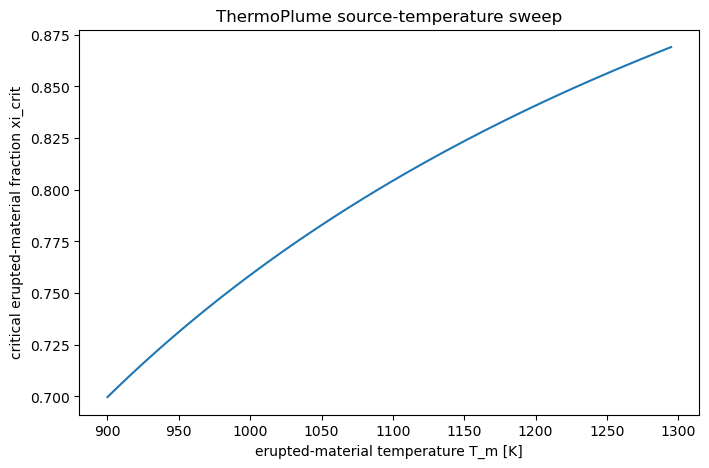

In [57]:
fig, ax = plt.subplots(
    figsize=(8, 5),
)

ax.plot(
    T_m_values,
    xi_Tm,
)

ax.set_xlabel("erupted-material temperature T_m [K]")
ax.set_ylabel("critical erupted-material fraction xi_crit")
ax.set_title("ThermoPlume source-temperature sweep")

plt.show()


## 13. Two-dimensional `Omega`–`T_m` sweep

A small two-dimensional sweep demonstrates the intended high-throughput use of the C++ numerical backend.

Cells with no physically admissible root remain `NaN`.


In [60]:
Omega_grid = np.linspace(
    0.0,
    0.50,
    41,
)

T_m_grid = np.linspace(
    900.0,
    1300.0,
    33,
)

xi_grid = np.full(
    (
        len(T_m_grid),
        len(Omega_grid),
    ),
    np.nan,
)

for i, T_m in enumerate(T_m_grid):
    previous_xi = None

    for j, Omega in enumerate(Omega_grid):
        p = replace(
            baseline,
            T_m=float(T_m),
            Omega=float(Omega),
        )

        result = ThermoPlumeModel(
            p
        ).solve(
            method="numerical",
            backend="cpp",
            previous_xi=previous_xi,
        )

        xi_grid[i, j] = result["xi_crit"]

        if np.isfinite(result["xi_crit"]):
            previous_xi = result["xi_crit"]


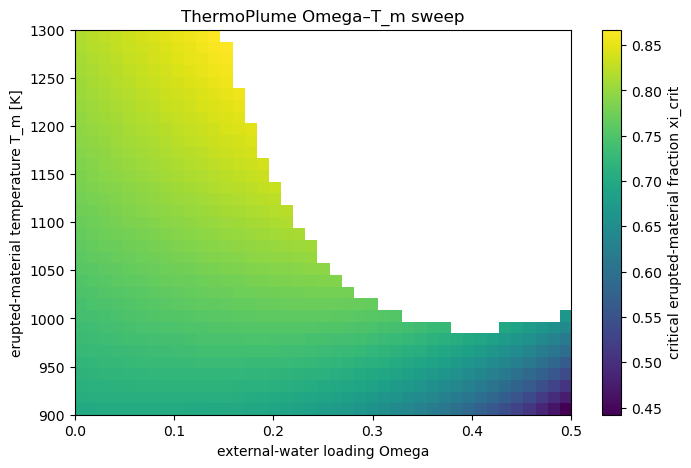

In [62]:
fig, ax = plt.subplots(
    figsize=(8, 5),
)

image = ax.imshow(
    xi_grid,
    origin="lower",
    aspect="auto",
    extent=[
        Omega_grid.min(),
        Omega_grid.max(),
        T_m_grid.min(),
        T_m_grid.max(),
    ],
)

ax.set_xlabel("external-water loading Omega")
ax.set_ylabel("erupted-material temperature T_m [K]")
ax.set_title("ThermoPlume Omega–T_m sweep")

cbar = fig.colorbar(
    image,
    ax=ax,
)

cbar.set_label(
    "critical erupted-material fraction xi_crit"
)

plt.show()


## 14. Parameters retained for later diagnostics

The current `ThermoPlumeParameters` container also includes:

- `C`
- `k`
- `rho_air`
- `rho_a`
- `g`
- `u0`
- `D`

These are useful plume/source quantities for additional diagnostics, including quantities such as critical Richardson-number calculations, but they do not currently enter the public `xi_crit` solver.

The following cell demonstrates that changing them leaves the present neutral-buoyancy threshold unchanged.


In [65]:
baseline_result = ThermoPlumeModel(
    baseline
).solve(
    method="numerical",
    backend="cpp",
)

diagnostic_parameter_case = replace(
    baseline,
    C=3.0,
    k=0.10,
    rho_air=1.0,
    rho_a=1.0,
    g=9.7,
    u0=150.0,
    D=100.0,
)

diagnostic_parameter_result = ThermoPlumeModel(
    diagnostic_parameter_case
).solve(
    method="numerical",
    backend="cpp",
)

print("baseline   ", baseline_result)
print("modified   ", diagnostic_parameter_result)

assert np.isclose(
    baseline_result["xi_crit"],
    diagnostic_parameter_result["xi_crit"],
    rtol=0.0,
    atol=0.0,
)

print("current xi_crit is unchanged")


baseline    {'xi_crit': 0.8043373275568237, 'regime': 'C', 'method': 'numerical', 'backend': 'cpp'}
modified    {'xi_crit': 0.8043373275568237, 'regime': 'C', 'method': 'numerical', 'backend': 'cpp'}
current xi_crit is unchanged


## 15. Suggested case-study workflow

For a case-specific application:

1. constrain or prescribe `T_m`
2. choose an ambient `T_air`
3. choose the external-water source and `T_w0`
4. determine the mixing pressure and calculate or obtain `T_sat`
5. define the volcanic-gas fraction `n`
6. define a consistent volcanic-gas composition and `R_g`
7. define the effective heat capacities
8. estimate or prescribe `Omega`
9. solve analytically and/or numerically
10. sweep uncertain inputs to determine sensitivity

This keeps environmental and petrologic assumptions explicit rather than hiding them inside the solver.


## 16. End

This notebook is intentionally an API and parameter tutorial.

